# Hydrogen atom using Gausslet orbitals

In [1]:
# see the README for build and install instructions of this package
import gausslectronitegrate as gli
from hydrogen_atom import (
    hydrogen_atom_groundstate_gausslets,
    evaluate_gausslet_wavefunction)

In [2]:
# Gausslet G10 coefficients
import sys
sys.path.append("../gausslets/")
from gausslets import get_gausslet_g10_coeffs
gausslet_coeffs, gausslet_indices = get_gausslet_g10_coeffs()

In [3]:
# list of grid lengths along each coordinate direction
grid_lengths = [9, 11, 13]

In [4]:
# list of grid scaling factors
scaling_list = [i / 40 for i in range(32, 61)]

In [5]:
en0_table  = {}
psi0_table = {}
for length in grid_lengths:
    en0_table[length], psi0_table[length] = \
        hydrogen_atom_groundstate_gausslets(gausslet_coeffs, length, scaling_list, tol_nuc=1e-5)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

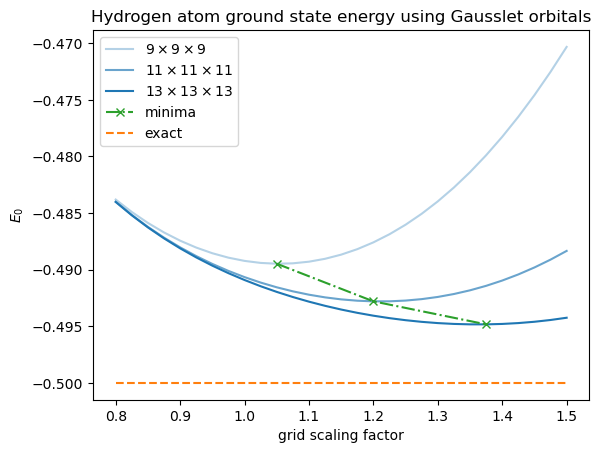

In [7]:
# visualize computed ground state energy in dependence of the scaling factor,
# for various grid lengths
idx_min = {}
for length in grid_lengths:
    idx_min[length] = int(np.argmin(en0_table[length]))
for il, length in enumerate(grid_lengths):
    plt.plot(scaling_list, en0_table[length], color="tab:blue", alpha=(il+1)/len(grid_lengths),
             label=rf"${length} \times {length} \times {length}$")
plt.plot([scaling_list[idx_min[length]] for length in grid_lengths],
         [en0_table[length][idx_min[length]] for length in grid_lengths], 'x-.',
         color="tab:green", label="minima")
plt.plot(scaling_list, len(scaling_list) * [-0.5], '--', color="tab:orange", label="exact")
plt.xlabel("grid scaling factor")
plt.ylabel(r"$E_0$")
plt.legend()
plt.title("Hydrogen atom ground state energy using Gausslet orbitals")
plt.savefig("hydrogen_atom_energy.pdf")
plt.show()

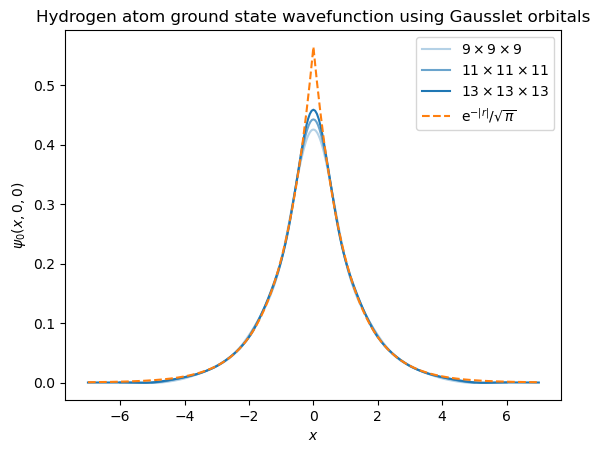

In [8]:
for il, length in enumerate(grid_lengths):
    idx_min = int(np.argmin(en0_table[length]))
    extent = (length - 1) // 2
    grid = [
        (-extent, length),  # x
        (-extent, length),  # y
        (-extent, length),  # z
    ]
    scaling = scaling_list[idx_min]
    xlist = np.linspace(-(extent + 1), extent + 1, 257)
    psi_x00 = np.array([evaluate_gausslet_wavefunction(
                            gausslet_coeffs, gausslet_indices, grid, scaling,
                            psi0_table[length][idx_min], [x, 0, 0])
                        for x in xlist])
    if psi_x00[len(xlist) // 2] < 0:
        psi_x00 = -psi_x00
    plt.plot(xlist, psi_x00, color="tab:blue", alpha=(il+1)/len(grid_lengths),
             label=rf"${length} \times {length} \times {length}$")
plt.plot(xlist, np.exp(-np.abs(xlist)) / np.sqrt(np.pi), '--',
         color="tab:orange", label=r"$\mathrm{e}^{-|r|} / \sqrt{\pi}$")
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$\psi_0(x, 0, 0)$")
plt.title("Hydrogen atom ground state wavefunction using Gausslet orbitals")
plt.savefig("hydrogen_atom_wavefunction.pdf")
plt.show()